In [11]:
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# ==========================================
# 1. LOAD DEPLOYED MODEL ARTIFACT & DATA
# ==========================================
artifact = joblib.load('credit_default_xgboost_model.pkl')
model = artifact['model']
threshold = artifact['optimal_threshold']
features = artifact['feature_cols']

data_path = '../modelData/master_modeling_matrix.csv'
df = pd.read_csv(data_path, index_col='loan_id')
df.index = df.index.astype(str)

X = df[features]
y = df['target']

# Use standard 80/20 test split (matching comparingBothModels.ipynb style)
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ==========================================
# 2. EVALUATE DEPLOYED MODEL ON TEST SET
# ==========================================
probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= threshold).astype(int)

cm = confusion_matrix(y_test.values, preds)
tn, fp, fn, tp = cm.ravel()

print('=' * 60)
print(f' DEPLOYED MODEL EVALUATION AT THRESHOLD = {threshold:.4f}')
print('=' * 60)
print(f' Total Loans in Test Set:              {len(y_test)}')
print(f' Total Actual Defaults in Test Set:    {tp + fn}')
print(f' Defaults Caught (True Positives):     {tp}')
print(f' Missed Defaults (False Negatives):    {fn}')
print(f' Safe Loans Approved (True Negatives): {tn}')
print(f' Safe Loans Flagged (False Positives): {fp}')
print('=' * 60)
print('\nClassification Report:')
print(
    classification_report(
        y_test.values, preds, target_names=['Approved (0)', 'Default (1)']
    )
)
print('=' * 60)

 DEPLOYED MODEL EVALUATION AT THRESHOLD = 0.2466
 Total Loans in Test Set:              137
 Total Actual Defaults in Test Set:    15
 Defaults Caught (True Positives):     15
 Missed Defaults (False Negatives):    0
 Safe Loans Approved (True Negatives): 75
 Safe Loans Flagged (False Positives): 47

Classification Report:
              precision    recall  f1-score   support

Approved (0)       1.00      0.61      0.76       122
 Default (1)       0.24      1.00      0.39        15

    accuracy                           0.66       137
   macro avg       0.62      0.81      0.58       137
weighted avg       0.92      0.66      0.72       137



Computing learning curves via 5-fold cross-validation...
Learning curves graph successfully saved to: ../learning_curves.png


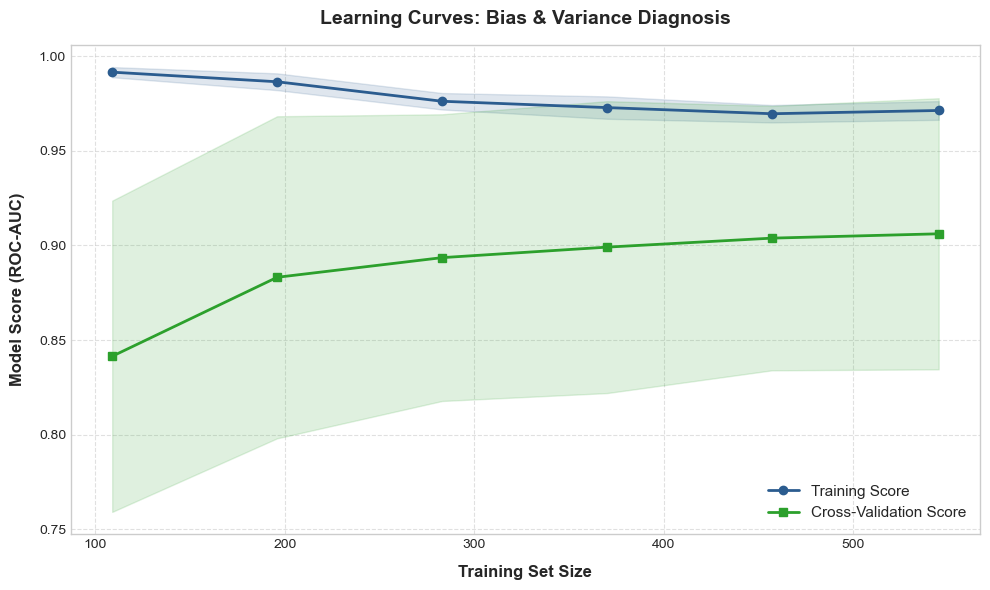

In [12]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import xgboost as xgb

# ==========================================
# 1. LOAD DATA & MODEL ARTIFACT
# ==========================================
data_dir = '../modelData'
matrix_path = os.path.join(data_dir, 'master_modeling_matrix.csv')
model_artifact_path = 'credit_default_xgboost_model.pkl'

master_df = pd.read_csv(matrix_path, index_col='loan_id')

# Separate features and target, ensuring only numeric data is used
X = master_df.drop(columns=['target'])
if 'loan_date' in X.columns:
    X = X.drop(columns=['loan_date'])
X = X.select_dtypes(include=['number']).fillna(0)
y = master_df['target']

# Load saved bundle to reuse exact hyperparameters
saved_bundle = joblib.load(model_artifact_path)
trained_model = saved_bundle['model']
params = trained_model.get_params()

# Initialize a fresh model instance with the same optimized settings
fresh_model = xgb.XGBClassifier(**params)

print("Computing learning curves via 5-fold cross-validation...")

# ==========================================
# 2. GENERATE LEARNING CURVES
# ==========================================
train_sizes, train_scores, val_scores = learning_curve(
    estimator=fresh_model,
    X=X,
    y=y,
    train_sizes=np.linspace(0.2, 1.0, 6),  # Evaluates from 20% to 100% of data chunks
    cv=5,                                   # 5-fold cross-validation
    scoring='roc_auc',                      # Track performance using ROC-AUC
    n_jobs=-1
)

# Calculate mean and standard deviation across folds
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# ==========================================
# 3. PLOT RESULTS
# ==========================================
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Training Score line and confidence interval
plt.plot(train_sizes, train_mean, label='Training Score', color='#2b5c8f', marker='o', linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='#2b5c8f', alpha=0.15)

# Cross-Validation Score line and confidence interval
plt.plot(train_sizes, val_mean, label='Cross-Validation Score', color='#2ca02c', marker='s', linewidth=2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, color='#2ca02c', alpha=0.15)

# Formatting layout
plt.title('Learning Curves: Bias & Variance Diagnosis', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Training Set Size', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Model Score (ROC-AUC)', fontsize=12, fontweight='bold', labelpad=10)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save figure locally
output_graph_path = '../learning_curves.png'
plt.savefig(output_graph_path, dpi=300)
print(f"Learning curves graph successfully saved to: {output_graph_path}")

plt.show()